In [71]:
pip install obspy numpy pandas matplotlib requests

Note: you may need to restart the kernel to use updated packages.


In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from obspy.taup import TauPyModel

In [73]:
# 1. MODEL BUMI AK135

# Memuat model Bumi ak135
model = TauPyModel(model="ak135")

# Parameter sumber
source_depth = 10.0  #km

# Jari-jari Bumi
earth_radius = 6371.0  #km

print("MODEL SIMULASI")
print("Model Bumi       :", "ak135")
print("Kedalaman sumber :", source_depth, "km")
print("Jari-jari Bumi   :", earth_radius, "km")

MODEL SIMULASI
Model Bumi       : ak135
Kedalaman sumber : 10.0 km
Jari-jari Bumi   : 6371.0 km


In [74]:
# 2. PERHITUNGAN TRAVEL TIME

# Jarak episentral
distances = np.arange(0.5, 180.1, 0.5)

# Menyimpan hasil
results = []

# Fase yang ingin dianalisis
phase_list = ["P", "PcP", "PKP"]

for distance in distances:

    # Menghitung semua arrival
    arrivals = model.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance,
        phase_list=phase_list
    )

    # Menyimpan semua arrival
    for arrival in arrivals:

        results.append({
            "Distance_deg": distance,
            "Phase": arrival.name,
            "TravelTime_s": arrival.time,
            "RayParameter_s_deg": arrival.ray_param_sec_degree
        })

# Membuat DataFrame
df = pd.DataFrame(results)

print("Jumlah hasil perhitungan:", len(df))

df.head(20)

Jumlah hasil perhitungan: 629


,Distance_deg,Phase,TravelTime_s,RayParameter_s_deg
0,0.5,PcP,509.961907,0.048031
1,1.0,P,19.400338,17.053209
2,1.0,P,19.823024,18.473230
3,1.0,P,20.073298,13.754236
4,1.0,P,20.448747,15.604389
5,1.0,PcP,509.997930,0.096052
6,1.5,P,26.950119,13.753044
7,1.5,P,27.926618,17.051970
8,1.5,P,28.515595,16.483967
9,1.5,P,29.166588,18.832037


In [75]:
# 3. TABEL HASIL

df_display = df.copy()

df_display.columns = [
    "Jarak Episentral (°)",
    "Fase",
    "Waktu Tempuh (s)",
    "Ray Parameter (s/°)"
]

print("HASIL SIMULASI AK135")
print("=" * 70)

display(df_display.head(30))

HASIL SIMULASI AK135


,Jarak Episentral (°),Fase,Waktu Tempuh (s),Ray Parameter (s/°)
0,0.5,PcP,509.961907,0.048031
1,1.0,P,19.400338,17.053209
2,1.0,P,19.823024,18.473230
3,1.0,P,20.073298,13.754236
4,1.0,P,20.448747,15.604389
5,1.0,PcP,509.997930,0.096052
6,1.5,P,26.950119,13.753044
7,1.5,P,27.926618,17.051970
8,1.5,P,28.515595,16.483967
9,1.5,P,29.166588,18.832037


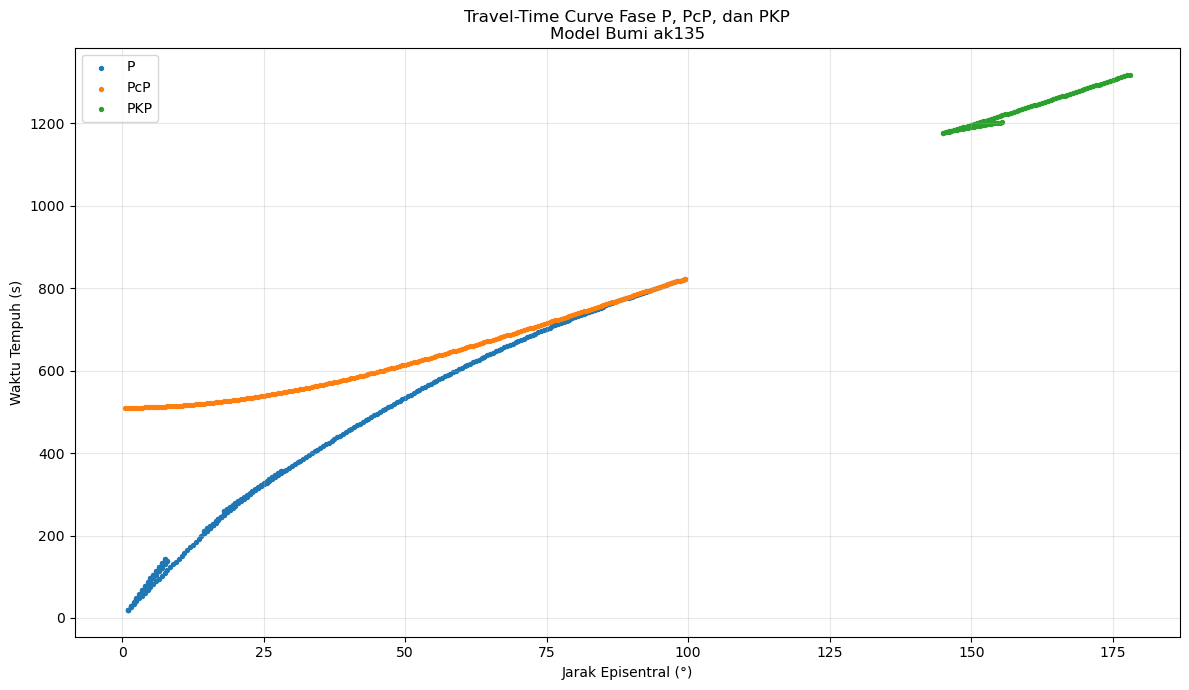

In [76]:
# 4. TRAVEL-TIME CURVE

plt.figure(figsize=(12, 7))

for phase in ["P", "PcP", "PKP"]:

    data = df[df["Phase"] == phase]

    plt.scatter(
        data["Distance_deg"],
        data["TravelTime_s"],
        s=8,
        label=phase
    )

plt.xlabel("Jarak Episentral (°)")
plt.ylabel("Waktu Tempuh (s)")
plt.title(
    "Travel-Time Curve Fase P, PcP, dan PKP\n"
    "Model Bumi ak135"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [77]:
# 5. IDENTIFIKASI SHADOW ZONE P

# Semua jarak yang dihitung
all_distances = set(distances)

# Jarak yang memiliki arrival P
p_distances = set(
    df[df["Phase"] == "P"]["Distance_deg"]
)

# Jarak yang tidak memiliki arrival P
shadow_distances = sorted(
    all_distances - p_distances
)

print("JUMLAH JARAK TANPA ARRIVAL P:", len(shadow_distances))




JUMLAH JARAK TANPA ARRIVAL P: 162


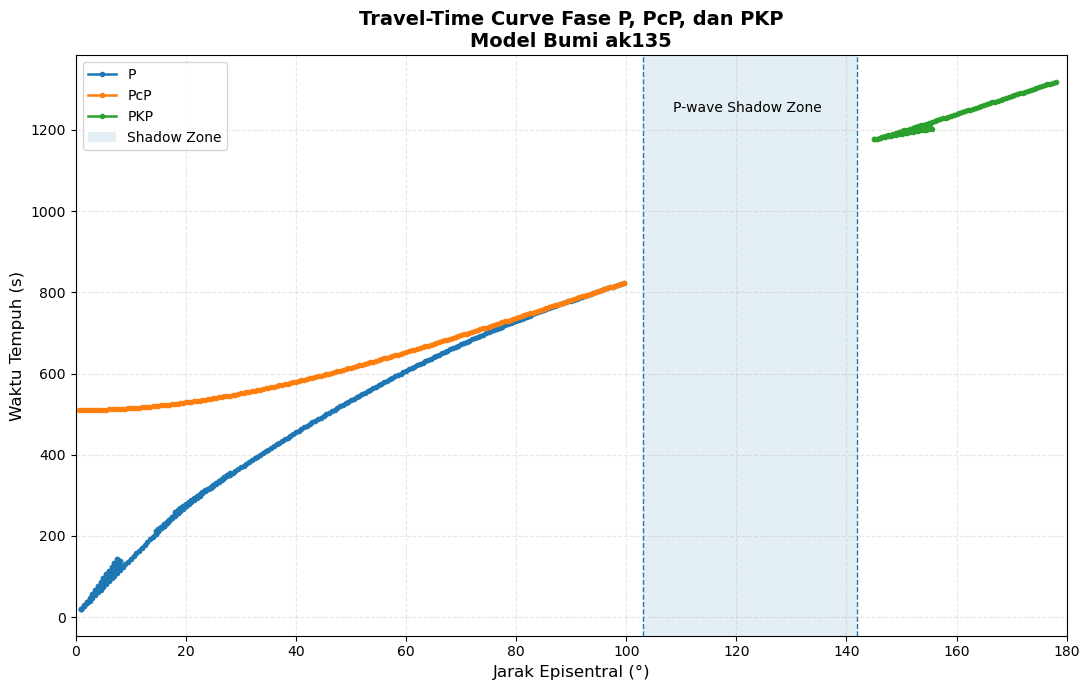

In [78]:
# 6. TRAVEL-TIME CURVE DAN SHAD0W ZONE

plt.figure(figsize=(11, 7))

for phase in ["P", "PcP", "PKP"]:

    data = df[df["Phase"] == phase].sort_values("Distance_deg")

    plt.plot(
        data["Distance_deg"],
        data["TravelTime_s"],
        marker="o",
        markersize=3,
        linewidth=1.8,
        label=phase
    )

# Shadow zone
plt.axvspan(
    103, 142,
    alpha=0.12,
    label="Shadow Zone"
)

# Garis batas shadow zone
plt.axvline(
    103,
    linestyle="--",
    linewidth=1
)

plt.axvline(
    142,
    linestyle="--",
    linewidth=1
)

# Label shadow zone
plt.text(
    122,
    plt.ylim()[1] * 0.90,
    "P-wave Shadow Zone",
    ha="center",
    fontsize=10
)

# Judul dan label
plt.xlabel(
    "Jarak Episentral (°)",
    fontsize=12
)

plt.ylabel(
    "Waktu Tempuh (s)",
    fontsize=12
)

plt.title(
    "Travel-Time Curve Fase P, PcP, dan PKP\n"
    "Model Bumi ak135",
    fontsize=14,
    fontweight="bold"
)

# Pengaturan grafik
plt.xlim(0, 180)
plt.grid(
    True,
    linestyle="--",
    alpha=0.3
)

plt.legend(
    frameon=True,
    loc="best"
)

plt.tight_layout()
plt.show()

In [95]:
# 7. PERHITUNGAN TRAVEL TIME DARI FASE PKP

# Jarak episentral
distances = np.arange(90, 180.1, 1)

# Menyimpan hasil
results = []

# Fase yang ingin dianalisis
phase_list = ["PKP"]

for distance in distances:

    # Menghitung semua arrival
    arrivals = model.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance,
        phase_list=phase_list
    )

    # Menyimpan SEMUA arrival
    for arrival in arrivals:

        results.append({
            "Distance_deg": distance,
            "Phase": arrival.name,
            "TravelTime_s": arrival.time,
            "RayParameter_s_deg": arrival.ray_param_sec_degree
        })

# Membuat DataFrame
df = pd.DataFrame(results)

print("Jumlah hasil perhitungan:", len(df))

df.head(45)

Jumlah hasil perhitungan: 45


,Distance_deg,Phase,TravelTime_s,RayParameter_s_deg
0,145.0,PKP,1176.730472,3.381219
1,145.0,PKP,1176.735941,3.529928
2,146.0,PKP,1179.905080,3.034512
3,146.0,PKP,1180.438419,3.805812
4,147.0,PKP,1182.835400,2.836217
5,147.0,PKP,1184.300966,3.917705
6,148.0,PKP,1185.582290,2.661984
7,148.0,PKP,1188.258360,3.994115
8,149.0,PKP,1188.170414,2.517341
9,149.0,PKP,1192.285987,4.056398


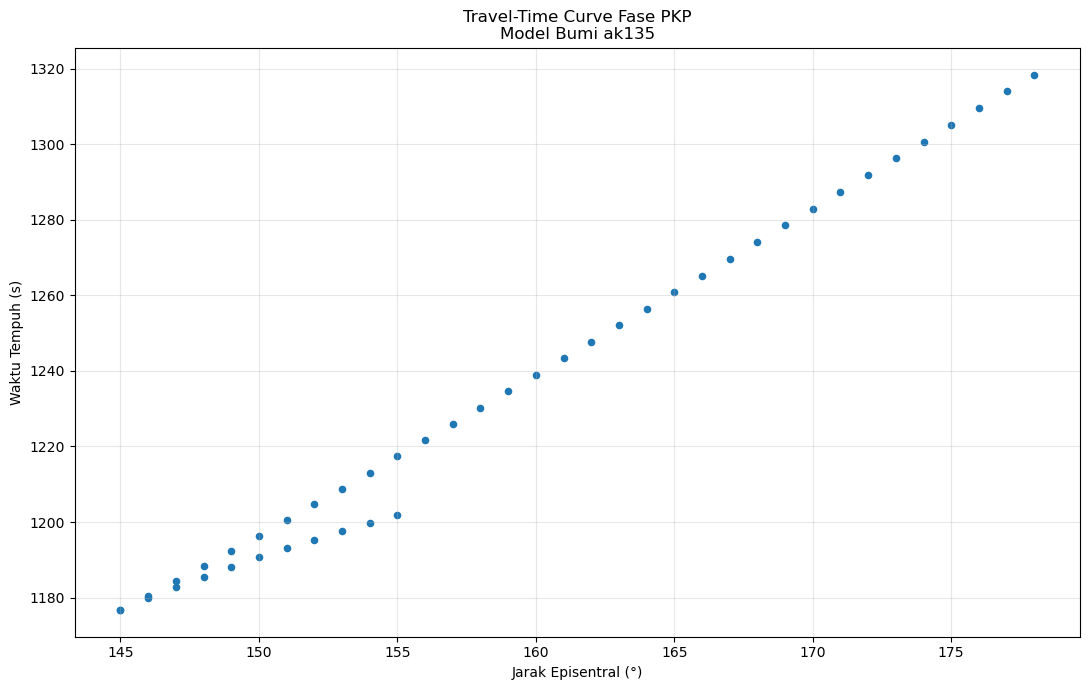

In [88]:
# 8. GRAFIK FASE PKP

plt.figure(figsize=(11, 7))

data = df[df["Phase"] == "PKP"]

plt.scatter(
    data["Distance_deg"],
    data["TravelTime_s"],
    s=20
)

plt.xlabel("Jarak Episentral (°)")
plt.ylabel("Waktu Tempuh (s)")
plt.title("Travel-Time Curve Fase PKP\nModel Bumi ak135")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [89]:
# 9. MULTI-ARRIVAL / TRIPLIKASI

trip_results = []

# Grid jarak yang lebih rapat
trip_distances = np.arange(20, 101, 0.5)

# Fase yang digunakan
trip_phases = ["P", "pP", "PP", "PcP"]

for distance in trip_distances:

    arrivals = model.get_travel_times(
        source_depth_in_km=source_depth,
        distance_in_degree=distance,
        phase_list=trip_phases
    )

    for arrival in arrivals:

        trip_results.append({
            "Distance_deg": distance,
            "Phase": arrival.name,
            "TravelTime_s": arrival.time,
            "RayParameter_s_deg": arrival.ray_param_sec_degree
        })

trip_df = pd.DataFrame(trip_results)

display(trip_df.head(30))



,Distance_deg,Phase,TravelTime_s,RayParameter_s_deg
0,20.0,P,272.676015,10.894833
1,20.0,P,274.399420,11.838128
2,20.0,P,274.618600,11.511496
3,20.0,pP,275.511646,10.905439
4,20.0,pP,277.108204,11.870994
5,20.0,pP,277.374964,11.509326
6,20.0,P,278.029558,9.225813
7,20.0,P,278.357584,9.488499
8,20.0,pP,281.051570,9.226686
9,20.0,pP,281.353578,9.479572


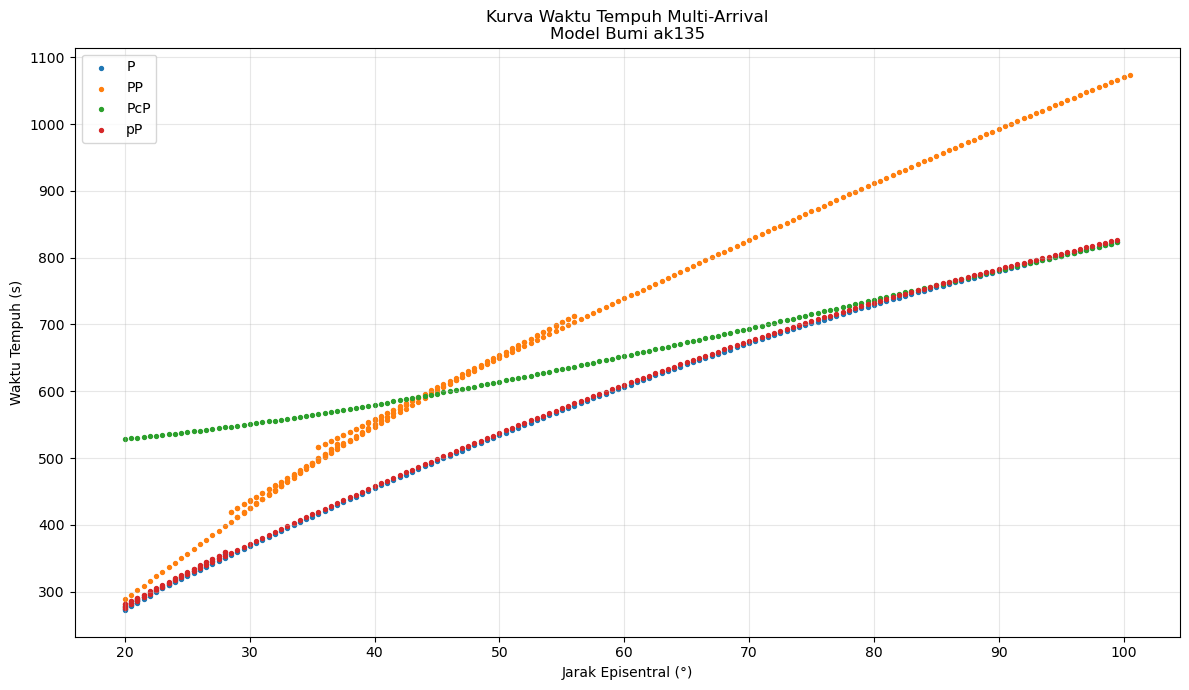

In [90]:
# 10. GRAFIK MULTI-ARRIVAL

plt.figure(figsize=(12, 7))

for phase in sorted(trip_df["Phase"].unique()):

    data = trip_df[trip_df["Phase"] == phase]

    plt.scatter(
        data["Distance_deg"],
        data["TravelTime_s"],
        s=8,
        label=phase
    )

plt.xlabel("Jarak Episentral (°)")
plt.ylabel("Waktu Tempuh (s)")
plt.title(
    "Kurva Waktu Tempuh Multi-Arrival\n"
    "Model Bumi ak135"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
#Mencari Triplikasi untuk PKP

pkp_data = df[df["Phase"] == "PKP"]

display(pkp_data.head())

,Distance_deg,Phase,TravelTime_s,RayParameter_s_deg
0,145.0,PKP,1176.730472,3.381219
1,145.0,PKP,1176.735941,3.529928
2,146.0,PKP,1179.905080,3.034512
3,146.0,PKP,1180.438419,3.805812
4,147.0,PKP,1182.835400,2.836217
